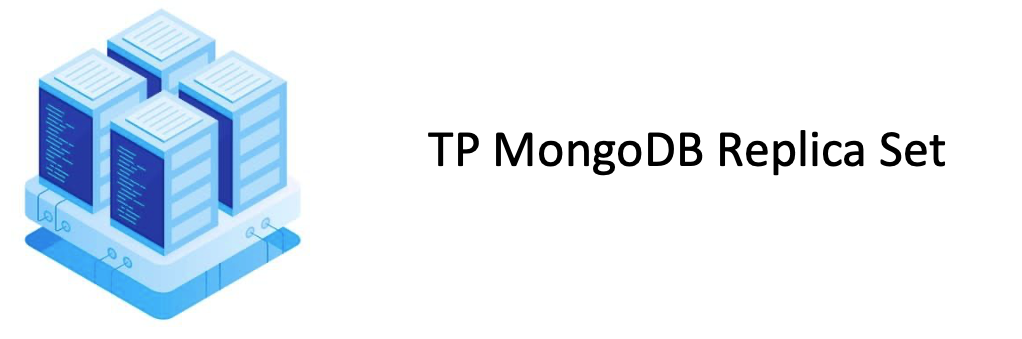



# Introduction — Réplication avec MongoDB

Et si votre serveur MongoDB devenait indisponible ?

Jusqu’à présent, nous avons utilisé MongoDB comme une base de données reposant sur une seule instance. Mais que se passe-t-il si cette instance tombe en panne ? L’application ne peut plus accéder à ses données.

Dans un environnement de production, la disponibilité d’une base de données est un enjeu essentiel. MongoDB répond à cette problématique grâce au mécanisme de réplication, basé sur les Replica Sets.

Un Replica Set est constitué de plusieurs instances MongoDB qui maintiennent des copies des mêmes données. Dans notre TP, nous allons construire un cluster composé de trois nœuds :


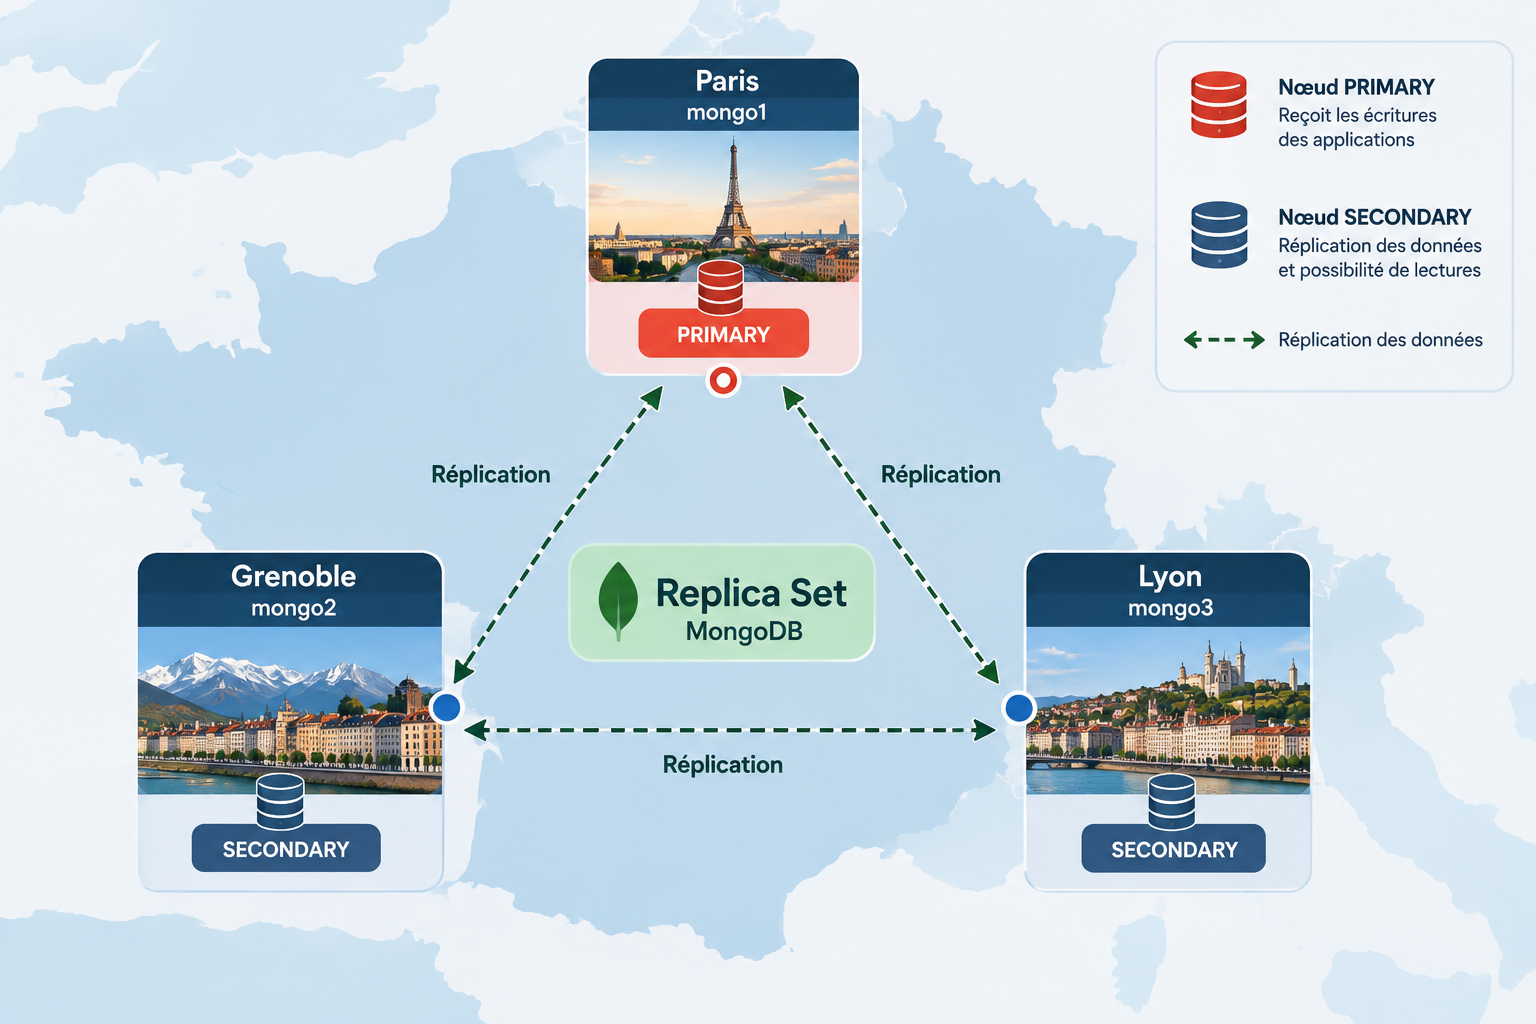


Les écritures sont dirigées uniquement vers le nœud PRIMARY, puis les opérations sont répliquées vers les nœuds SECONDARY.

Mais la réplication ne sert pas uniquement à conserver plusieurs copies des données. Au cours de ce TP, nous verrons qu’elle peut être utilisé pour absorber une charge en lecture plus importante.


:::{important}Objectifs pédagogiques

À l’issue de ce TP, vous serez capables de :

* déployer et initialiser un Replica Set MongoDB à trois nœuds ;
* identifier les rôles PRIMARY et SECONDARY et observer l’état de la réplication ;
* comprendre comment MongoDB assure la haute disponibilité grâce au mécanisme d’élection ;
* exploiter les nœuds secondaires pour effectuer des lectures ;
* comprendre et expérimenter différentes stratégies de répartition des lectures ;
* appréhender l’impact des choix de lecture et d’écriture sur la cohérence des données.
:::

Le défi de ce TP : passer d’une simple instance MongoDB à un véritable système distribué et comprendre les compromis entre disponibilité, performances et cohérence.



## Mise en situation

Dans le cadre de ce TP, nous allons simuler une infrastructure MongoDB géographiquement distribuée sur trois sites :

* 🇫🇷 Paris : une instance MongoDB ;
* 🏔️ Grenoble : une instance MongoDB ;
* 🦁 Lyon : une instance MongoDB.

Ces trois instances seront regroupées au sein d’un même Replica Set MongoDB. L’objectif sera d’observer comment MongoDB réplique les données entre les différents nœuds et assure la continuité du service lorsqu’une instance devient indisponible.

:::{note}Simplification du TP : 
Afin de nous concentrer sur les mécanismes de réplication et de haute disponibilité, nous ne traiterons pas ici les aspects liés à la sécurité, notamment l’authentification entre les clients et MongoDB ainsi qu’entre les membres du Replica Set.
:::

# Préparer l’environnement

Ouvrez un terminal SSH ou PowerShell depuis la racine du dépôt, puis placez-vous dans le répertoire docker :

```
cd docker
```

Au cours de ce TP, nous utiliserons jusqu’à cinq terminaux simultanément. Afin de faciliter leur identification, ils seront nommés :

```
#term1   #term2   #term3   #term4   #term5
```

:::{warning} Soyez attentifs au terminal utilisé !
Chaque cellule de commande indiquera explicitement le numéro du terminal dans lequel la commande doit être exécutée.
:::

Notre premier terminal, #term1, sera réservé exclusivement aux commandes Docker : démarrage et arrêt des conteneurs, vérification de leur état, consultation des logs, etc.


Gardez donc #term1 ouvert pendant toute la durée du TP.

:::bash
cd docker
docker compose up -d mongosingle
docker compose ps mongosingle
:::

# Déploiement d'une cluster MongoDB en mode réplica

Dans cette section, vous allez déployer trois conteneurs MongoDB (mongo1, mongo2, mongo3), chacun instanciant une instance de MongoDB. 
Vous configurerez ces instances pour permettre une communication entre elles, formant ainsi un cluster en mode réplica.

Ce cluster sera composé d'un nœud primaire et de deux nœuds secondaires, conformément à la description ci-dessous :

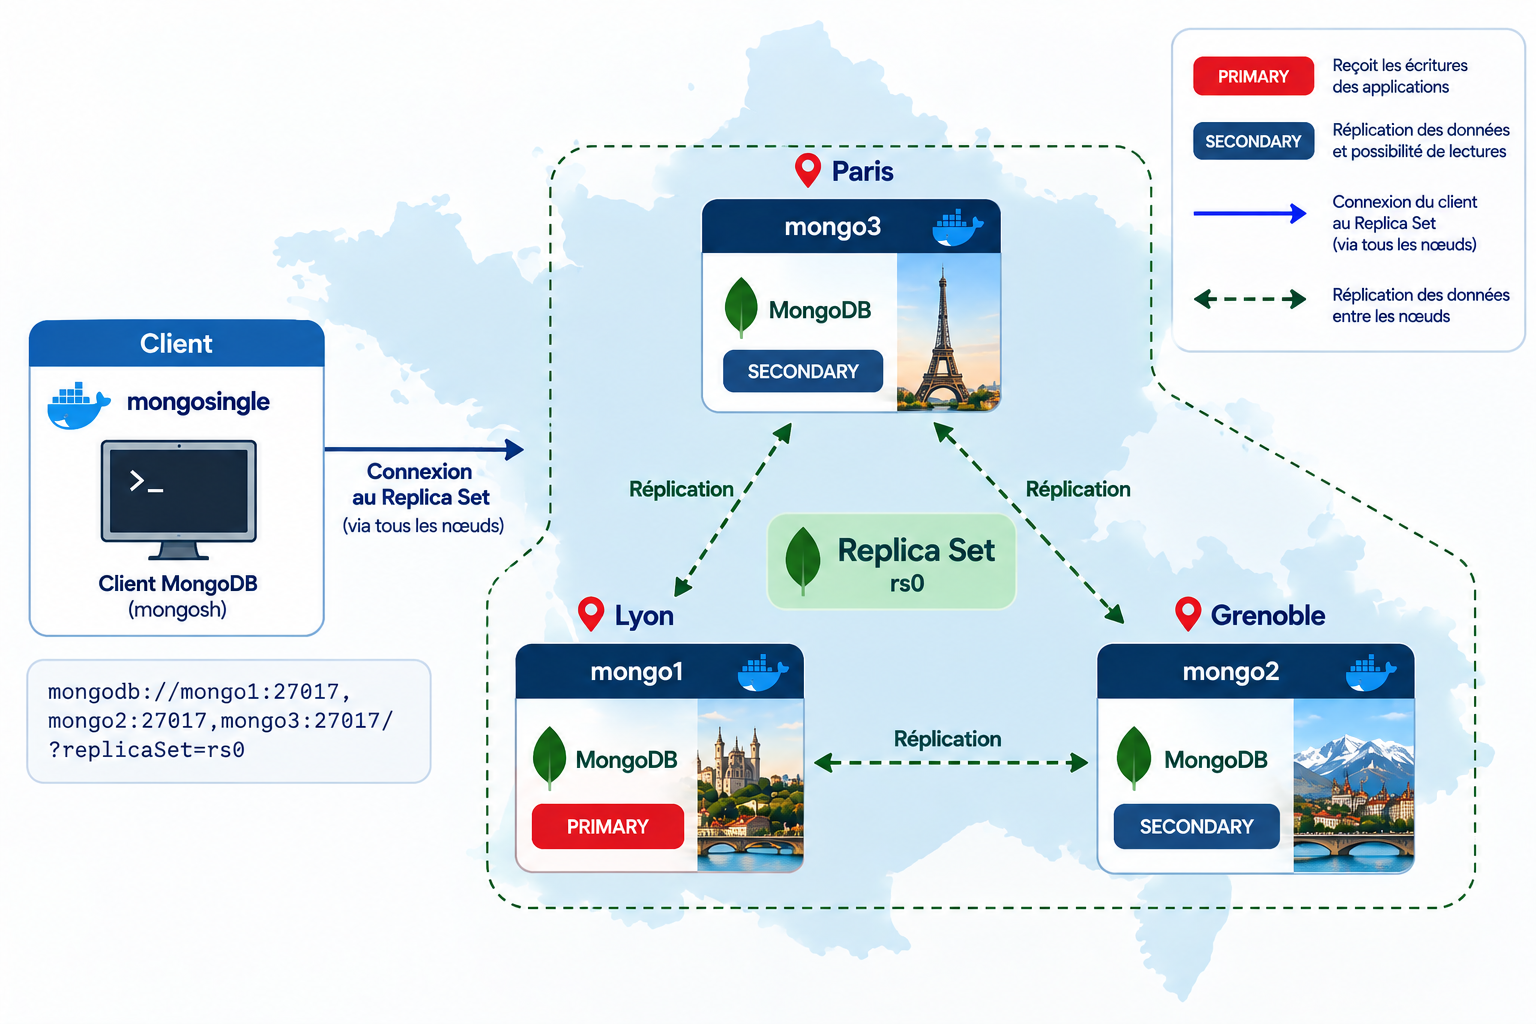

On utilisera le fichier de configuration `docker-compose.yml` pour construire notre cluster en utilisant les trois conteneurs mongo1, mongo2 et mongo3.

## 1 - Instancier les conteneurs mongo1, mongo2 et mongo3

Démarrer vos conteneurs mongo1, mongo2 et mongo3.


```
#term1
docker compose up -d mongo1 mongo2 mongo3
docker compose ps mongo1 mongo2 mongo3
```

####  A partir de la documentation MongoDB ci-dessous, expliquer ce que réalise le service mongoinit de votre docker-compose.yml ?

:::{tip}Aide
La procédure pour implémenter un cluster en replica set est décrite ici :
[https://www.mongodb.com/docs/v4.4/tutorial/deploy-replica-set/#deploy-a-replica-set-in-the-terminal](https://www.mongodb.com/docs/v4.4/tutorial/deploy-replica-set/#deploy-a-replica-set-in-the-terminal)
:::


:::{admonition} Solution
:class: dropdown

Le service `mongoinit` se connecte à `mongo1` et exécute `rs.initiate()` avec la configuration du Replica Set et la liste de ses membres.

Cette commande enregistre la configuration et déclenche la découverte des membres, leurs heartbeats et l'élection d'un PRIMARY. Chaque membre conserve ensuite les opérations dans son oplog ; les SECONDARY s'en servent pour répliquer les écritures du PRIMARY. L'initialisation ne copie donc pas directement les journaux vers chaque membre.
:::

Exécuter le service mongoinit :



## 2 - Connexion au cluster MongoDB

Pour se connecter à notre cluster fraichement configuré, ouvrez un terminal qu'on appellera #term2.

A partir du terminal #term2 instancier notre conteneur `mongosingle` pour l'utiliser en tant que client pour accéder à notre cluster .

Votre container mongosingle dispose d'un client `mongo` pour nous connecter à distance à notre cluster Mongo.

#### A partir de la documentation ci-dessous établissez une connexion à votre cluster sur la base training ?

[Connection-string ](https://www.mongodb.com/docs/manual/reference/connection-string/?deployment-type=self&interface-atlas-only=None&topology=replica-set&connection-string-format=srv#replica-set-with-members-on-different-hosts)

:::{note} Authentification
Dans notre configuration actuelle, nous n'aurons pas besoin de spécifier de login / mdp
:::

:::{admonition} Solution
:class: dropdown

```bash
mongo "mongodb://mongo1:27017,mongo2:27017,mongo3:27017/training?replicaSet=my-mongo-set"
```

La liste des hôtes permet au pilote de découvrir le Replica Set. Le paramètre `replicaSet` doit correspondre au nom défini dans la configuration (`my-mongo-set`).
:::

Pour obtenir les informations sur le Replica Set, MongoDB fournit la commande `rs.status()`.

#### Identifiez le nœud PRIMARY et les nœuds SECONDARY dans le résultat. Notez leurs noms et leurs rôles ; ils peuvent varier d'une exécution à l'autre.

:::{admonition} Solution
:class: dropdown

Exécuter `rs.status()` et relever pour chaque entrée de `members` les champs `name` et `stateStr`. Les valeurs `PRIMARY` et `SECONDARY` indiquent les rôles au moment de la commande. L'identité du PRIMARY peut changer à la suite d'une élection ; il ne faut donc pas retenir les rôles de l'exemple comme une valeur fixe.
:::

# La réplication au service de la performance

## Introduction

Dans cette section, nous explorerons l'utilisation des instances MongoDB ayant le rôle "secondary" pour optimiser les performances.

Cette portion sera divisée en deux sections :
* Favoriser l'accès en lecture sur les instances "secondary"
* Définir une stratégie de répartition des lectures sur les instances "secondary"



## Privilégier les accès en lecture sur les "secondary"
Nous allons utiliser les instances secondaires pour améliorer les accès en lecture sur nos données :

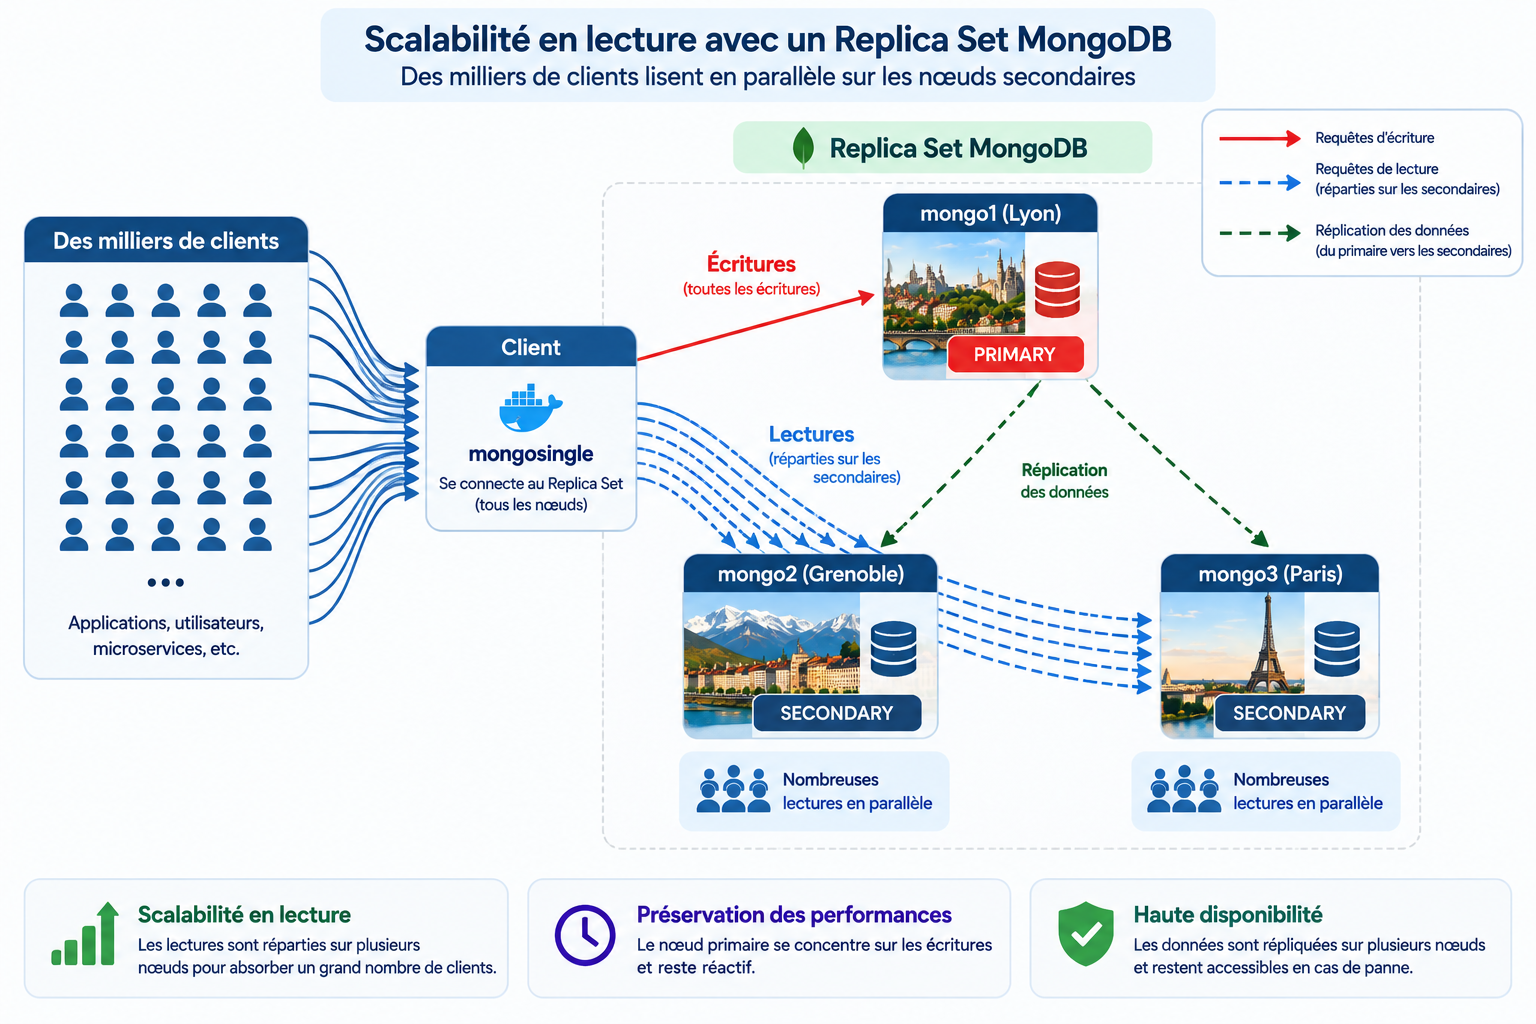


À partir du terminal #term1, nous allons maintenant charger le jeu de données (movies)  dans la base training de notre Replica Set.

L’import sera réalisé à l’aide du service Docker mongodataimport. Les données seront envoyées au nœud mongo1, actuellement PRIMARY du Replica Set.

Une fois les données écrites sur le PRIMARY, nous pourrons vérifier qu’elles sont bien répliquées vers les nœuds SECONDARY.
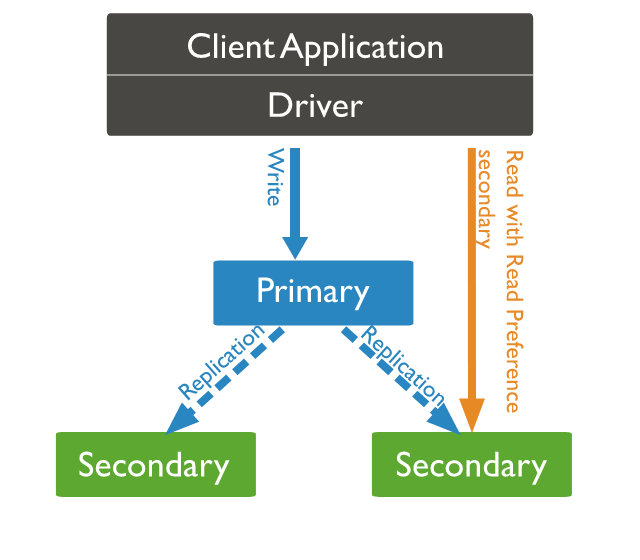

Vérifions que nos données sont bien répliquées sur l'ensemble de nos instances mongo1, mongo2 et mongo3.

:::{note} Note
Pour permettre les lectures sur un mongo secondaire, il sera nécessaire d'autoriser les lectures avec la méthode db.getMongo().setSecondaryOk()

[https://www.mongodb.com/docs/v4.4/reference/method/Mongo.setSecondaryOk/](https://www.mongodb.com/docs/v4.4/reference/method/Mongo.setSecondaryOk/)
:::
    
Pour cela, ouvrer 3 terminaux term3, term4 et term5 et connectez vous directement à chaque instance mongodb

✅ Vous obtenez normalement 88 documents sur chaque instance.

Parfait ! Nos données sont correctement répliquées sur les différents membres du Replica Set. Nous pouvons continuer ! 🚀

Afin de déterminer sur quel nœud du Replica Set nos requêtes de lecture sont réellement exécutées, nous allons activer le profiler MongoDB sur chacun des membres.

Pour ce TP, nous utiliserons le niveau 2, qui enregistre toutes les opérations exécutées sur la base dans la collection : system.profile

Cette collection est locale à chaque membre du Replica Set et n’est pas répliquée. Nous pourrons donc l’interroger sur mongo1, mongo2 et mongo3 afin d’identifier précisément quel nœud a traité une requête.

:::{warning} Attention : 
Le niveau 2 enregistre toutes les opérations et peut générer une charge importante. Nous l’utilisons ici uniquement dans le cadre de ce TP, sur notre petit jeu de données de laboratoire. Il ne doit pas être activé ainsi sans précaution sur une base de production.
:::


Pour les exercices suivants, nous allons créer une seconde collection nommée copymovies, à partir de notre collection movies.

Utilisez le terminal #term2, connecté au Replica Set avec la chaîne de connexion utilisée précédemment.


On va à présent utiliser les terminaux term3, term4 et term5 pour tracer l'activité sur notre cluster. 

Vous disposez donc de 5 terminaux :

* term1: pour passer des commandes docker
* term2 : connexion au cluster
* term3, term4, term4 tracent respectivement l'activité sur les instances mongo1, mongo2 et mongo3. 

Commençons à jouer avec notre cluster !

Le choix de lire les données sur le primaire est la valeur par défaut prise par le client.

On peut modifier ce comportement en précisant dans note chaine de connexion nos préférences en lecture avec le paramètre read_preference ou en modifiant la valeur de notre session avec la méthode   setReadPref.

Essayons avec notre session en cours sur le terminal 2 :

Notre session va donc envoyer toutes les lectures sur les "secondary" et pour vérifier le comportement nous allons garder un oeil sur les logs Mongodb.

Sur votre terminal 2, connectez vous  la base training pour effectuer vos requêtes :

En consultant les logs des terminaux 3,4 et 5, vous remarquerez que l'un des terminaux affiche la trace de vos requêtes exécutées :


Si vous identifiez le container mongo qui a pris en charge la requête vous remarquerez qu'il s'agit d'un "secondary" .

C'est cool vous trouvez pas !!! 

La fonction de router est assurée par le client lui-même et c'est lui qui va rediriger les requêtes sur les instances secondaires de MongoDB.

Dans le cas d'une application, la version des drivers sera un élément critique pour veiller à la bonne répartition des requêtes.

En effet, le client fait parti du cluster et est abonné aux évènements qui se produit sur le cluster.

Pour utiliser le mode readpreference, on peut aussi le spécifier lors de la connexion comme on vient de le faire avec  `db.getMongo().setReadPref('secondary')` ou dans la chaine de connexion :


:::{warning} ATTENTION

Le client mongo shell dont la version est inférieur à 5 présente un bug empêchant l'interprétation correcte de l'option dans la chaîne de connexion (cf [https://jira.mongodb.org/browse/SERVER-39222](https://jira.mongodb.org/browse/SERVER-39222)).

En conséquence, dans cette situation, votre seul choix viable serait d'opter pour l'utilisation de la commande `db.getMongo().setReadPref({mode:'secondary'})`.

:::

Gardez les connexions directes ouvertes dans les terminaux #term3, #term4 et #term5. Après avoir exécuté une lecture depuis #term2, consultez `system.profile` sur chacun des nœuds pour voir où la requête a été exécutée. L'enregistrement du profiler est local à chaque instance.

Vous disposez donc de cinq terminaux :

* #term1 : commandes Docker ;
* #term2 : connexion au Replica Set ;
* #term3, #term4 et #term5 : connexions directes à mongo1, mongo2 et mongo3 pour consulter leur `system.profile`.

Le PRIMARY est élu par le Replica Set et n'est pas garanti par le nom du conteneur. Vérifiez son rôle avec `rs.status()`.

La préférence de lecture par défaut est `primary`. Avec `secondary`, le pilote sélectionne un SECONDARY admissible ; le choix peut varier selon la disponibilité et les règles de sélection du pilote. Exécutons une lecture depuis #term2 :

Avec la préférence `secondary`, le pilote envoie les lectures vers un SECONDARY admissible. Le nœud effectivement choisi peut varier ; vérifiez quel membre a traité la requête en consultant `system.profile` sur chacun d'eux.

Dans les terminaux 3, 4 et 5, consultez `db.system.profile` pour déterminer quel nœud a enregistré la lecture :

Le pilote MongoDB surveille la topologie du Replica Set (membres, rôles et disponibilité) et sélectionne un serveur admissible selon la préférence de lecture et les règles de sélection du pilote. Le client n'est pas lui-même un membre du Replica Set. Pour une préférence `secondary`, plusieurs nœuds peuvent être admissibles ; la requête n'est donc pas garantie d'aller toujours sur le même SECONDARY.

La préférence peut aussi être spécifiée dans la chaîne de connexion avec `readPreference=secondary`.

:::{warning} ATTENTION

Le client mongo shell dont la version est inférieur à 5 présente un bug empêchant l'interprétation correcte de l'option dans la chaîne de connexion (cf [https://jira.mongodb.org/browse/SERVER-39222](https://jira.mongodb.org/browse/SERVER-39222)).

En conséquence, dans cette situation, votre seul choix viable serait d'opter pour l'utilisation de la commande `db.getMongo().setReadPref({mode:'secondary'})`.

:::

Ainsi, il est possible de décharger les opérations de lecture du `primaire` vers les `secondaires`, préservant ainsi le `primaire` pour les opérations d'écriture.

Cette architecture permet une mise à l'échelle, ou extensibilité, en termes d'opérations de lecture. Toutefois, cette solution présente des limitations pour les opérations en écriture.

De plus, cette approche primaire/secondaire peut entraîner l'exécution d'opérations de lecture sur des secondaires éloignés du client, ce qui peut potentiellement augmenter les temps de réponse. 
Imaginons qu'un client situé à Grenoble accède à l'instance MongoDB à Paris, les délais de communication seront plus longs que s'il communiquait avec l'instance de Grenoble.

Pour remédier à cette problématique, MongoDB a mis en place une solution reposant sur l'utilisation de TAGs.

### Stratégie de répartition des lectures sur les "secondary"

Afin de faire face à la mondialisation croissante des applications, il est recommandé d'optimiser la proximité des données par rapport aux applications.

Il peut donc être astucieux de déployer des nœuds secondaires MongoDB dans des emplacements géographiques aussi proches que possible de vos applications. Dans de nombreux systèmes de gestion de base de données NoSQL, l'utilisation de tags permet de qualifier la situation géographique des instances secondaires, offrant ainsi aux clients la possibilité de sélectionner le nœud secondaire le plus proche d'eux.

Dans le contexte de notre cluster MongoDB, supposons que notre application soit répartie entre Lyon, Grenoble et Paris.

Étant donné que le site principal est basé à Lyon, nous avons mis en place un cluster avec le nœud primaire hébergé à Lyon et les nœuds secondaires à Grenoble et Paris.

Afin de spécifier la localisation géographique de chaque instance MongoDB, nous allons associer un tag "ville" à chaque membre dans la configuration du cluster.

Pour effectuer cette opération, vous devrez modifier la configuration du cluster MongoDB, en rétablissant ensuite le mode en tant que "primaire" pour que vos modifications prennent effet.


#### A partir de la documentation MongoDB ci-dessous associer un tag ville à chaque membre du cluster :

[https://www.mongodb.com/docs/v4.4/tutorial/configure-replica-set-tag-sets/](https://www.mongodb.com/docs/v4.4/tutorial/configure-replica-set-tag-sets/)

On supposera dans cet exercice que : 
* mongo1 est à Lyon
* mongo2 est à Grenoble
* mongo3 est à Paris

:::{admonition} Solution
:class: dropdown

```javascript
config = rs.config()
config.members[0].tags = {'ville': 'Lyon'}
config.members[1].tags = {'ville': 'Grenoble'}
config.members[2].tags = {'ville': 'Paris'}
rs.reconfig(config)
rs.config()
```

Les tags sont attachés aux membres de la configuration. Après `rs.reconfig()`, ils peuvent être utilisés par les préférences de lecture pour filtrer les SECONDARY admissibles.
:::

Les membres sont maintenant dotés de labels, et nous pouvons désormais utiliser ces TAGs pour orienter les lectures non seulement en fonction du rôle (secondary/primary), mais également en fonction du TAG.

#### Sur le terminal 2, veuillez ajuster les préférences de lecture afin de rediriger les requêtes vers le site de Paris ?

[https://www.mongodb.com/docs/v4.4/reference/method/Mongo.setReadPref/](https://www.mongodb.com/docs/v4.4/reference/method/Mongo.setReadPref/)

:::{admonition} Solution
:class: dropdown

```javascript
db.getMongo().setReadPref('secondary', [{'ville': 'Paris'}])
db.getMongo().getReadPref()
```

Le tag `ville: Paris` correspond au SECONDARY `mongo3` dans la topologie pédagogique. Les tags filtrent les membres admissibles ; le pilote choisit parmi les membres qui satisfont les critères.
:::

En utilisant notre fameuse db training, exécuter une requête MongoDB sur la collection training.movies et consulter les logs de l'instance mongo3 :


:::{admonition} Solution
:class: dropdown

```javascript
use training
db.movies.find({_id: 'movie:13'})
```

Avec la préférence `secondary` et le tag `{ville: 'Paris'}`, le résultat attendu dans cette topologie est une lecture sur le membre taggé Paris (`mongo3`). Confirmez-le dans la collection locale `system.profile` de ce nœud ; n'utilisez pas une trace de log horodatée comme résultat fixe.
:::

Avec cette approche, il devient relativement aisé de diriger/distribuer les requêtes en fonction du niveau de performance et de cohérence désiré.

Nous avons constaté qu'il est possible de spécifier des préférences de lecture en fonction du mode primaire/secondaire ou de l'étiquette d'un membre du cluster. Il est toutefois important de noter que les bibliothèques de programmation offrent des fonctionnalités plus avancées, permettant de définir des préférences spécifiques à la base de données ou à la collection interrogée.

L'exemple ci-dessous présente un simple programme Python qui établit des préférences sur les secondaires pour la base de données "training":

Le code suivant est directement exécutable à partir du notebook. Il vous suffit de cliquer sur `run`.

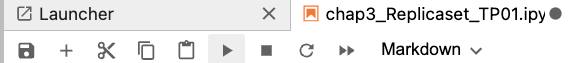

In [1]:
from pymongo import MongoClient
from pymongo.read_preferences import Secondary

client = MongoClient('mongodb://mongo1:27017,mongo2:27017,mongo3:27017/?replicaSet=my-mongo-set')
training = client.get_database(
    'training',
    read_preference=Secondary()
)

for doc in training.movies.find({'_id': 'movie:15'}):
    print(doc)

client.close()

ServerSelectionTimeoutError: mongo1:27017: [Errno -2] Name or service not known (configured timeouts: socketTimeoutMS: 20000.0ms, connectTimeoutMS: 20000.0ms),mongo2:27017: [Errno -2] Name or service not known (configured timeouts: socketTimeoutMS: 20000.0ms, connectTimeoutMS: 20000.0ms),mongo3:27017: [Errno -2] Name or service not known (configured timeouts: socketTimeoutMS: 20000.0ms, connectTimeoutMS: 20000.0ms), Timeout: 30s, Topology Description: <TopologyDescription id: 6aba8fcee5e5cd1e3fa12283, topology_type: ReplicaSetNoPrimary, servers: [<ServerDescription ('mongo1', 27017) server_type: Unknown, rtt: None, error=AutoReconnect('mongo1:27017: [Errno -2] Name or service not known (configured timeouts: socketTimeoutMS: 20000.0ms, connectTimeoutMS: 20000.0ms)')>, <ServerDescription ('mongo2', 27017) server_type: Unknown, rtt: None, error=AutoReconnect('mongo2:27017: [Errno -2] Name or service not known (configured timeouts: socketTimeoutMS: 20000.0ms, connectTimeoutMS: 20000.0ms)')

#### A partir du programme ci-dessus modifier le code afin que la base training lise les données sur Grenoble :

Indice : la documentation pymongo vous sera utile 
https://pymongo.readthedocs.io/en/stable/examples/high_availability.html?highlight=read_preference

:::{admonition} Solution
:class: dropdown

```python
from pymongo import MongoClient
from pymongo.read_preferences import Secondary

client = MongoClient('mongodb://mongo1:27017,mongo2:27017,mongo3:27017/?replicaSet=my-mongo-set')
training = client.get_database(
    'training',
    read_preference=Secondary([{'ville': 'Grenoble'}])
)

for doc in training.movies.find({'_id': 'movie:15'}):
    print(doc)

client.close()
```

La préférence `Secondary` avec un tag `ville=Grenoble` filtre les membres SECONDARY admissibles. 
:::

#### Modifier le code python afin que les préférences de read respectent les contraintes suivantes ?
* les accès en lecture sur la collection movies sont réalisés sur le primaire
* les accès en lecture sur la collection copymovies sont réalisés sur l'instance Grenoble


:::{tip} Indice : 
la documentation pymongo vous sera utile 
[https://pymongo.readthedocs.io/en/stable/examples/high_availability.html?highlight=read_preference](https://pymongo.readthedocs.io/en/stable/examples/high_availability.html?highlight=read_preference)
::: 

In [7]:
# Votre réponse Python : définir movies en PRIMARY et copymovies sur le SECONDARY Grenoble, puis exécuter une lecture sur chaque collection.

ldskncksdcnsjkldc


{'_id': 'movie:15', 'title': 'Twelve Monkeys', 'year': 1995, 'genre': 'Science-fiction', 'summary': None, 'country': 'USA', 'director': {'_id': 'artist:33', 'last_name': 'Gilliam', 'first_name': 'Terry', 'birth_date': '1940'}, 'actors': [{'_id': 'artist:27', 'first_name': 'Bruce', 'last_name': 'Willis', 'birth_date': '1955', 'role': 'Cole'}]}
{'_id': 'movie:15', 'title': 'Twelve Monkeys', 'year': 1995, 'genre': 'Science-fiction', 'summary': None, 'country': 'USA', 'director': {'_id': 'artist:33', 'last_name': 'Gilliam', 'first_name': 'Terry', 'birth_date': '1940'}, 'actors': [{'_id': 'artist:27', 'first_name': 'Bruce', 'last_name': 'Willis', 'birth_date': '1955', 'role': 'Cole'}]}


:::{admonition} Solution
:class: dropdown

```python
from pymongo import MongoClient, ReadPreference
from pymongo.read_preferences import Secondary

client = MongoClient('mongodb://mongo1:27017,mongo2:27017,mongo3:27017/?replicaSet=my-mongo-set')
training = client.get_database('training')

movies = training.get_collection(
    'movies', read_preference=ReadPreference.PRIMARY
)
copymovies = training.get_collection(
    'copymovies', read_preference=Secondary([{'ville': 'Grenoble'}])
)

for doc in movies.find({'_id': 'movie:15'}):
    print(doc)
for doc in copymovies.find({'_id': 'movie:15'}):
    print(doc)

client.close()
```

Les préférences se définissent par collection. Confirmez leur effet en inspectant `system.profile` sur le PRIMARY courant et sur le SECONDARY Grenoble.
:::

Le client MongoDB nous donne assez de flexibilité pour définir nos préférences afin d'améliorer les performances mais qu'en est il du niveau du cohérence ?

C'est ce que nous allons voir dans la section suivante.

## La cohérence

Pour rappel, le thèoreme de CAP est l'acronyme de :
* Consistency (cohérence): La cohérence signifie que tous les clients voient les mêmes données en même temps, quel que soit le nœud auquel ils se connectent.
* Availability (disponibilité): La disponibilité signifie qu'un client qui effectue une requête de données obtient une réponse, même si un ou plusieurs nœuds sont en panne.
* Partition Tolerance (distribution): La tolérance au partitionnement signifie que la grappe (cluster) doit continuer à fonctionner quel que soit le nombre d'interruptions entre les nœuds du système.

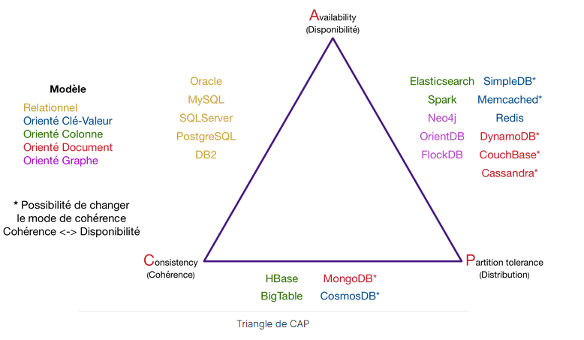

Dans la figure ci-dessus MongoDB est classé CP sur le théorème et nous allons voir que ce n'est pas tout à fait vrai.

### Write concern

Le write concern définit le nombre ou le type d'acquittements exigés avant que le client considère une écriture comme acquittée. Il ne signifie pas que toutes les copies sont mises à jour simultanément : les SECONDARY appliquent les opérations après leur réception depuis l'oplog.

Avec trois membres votants et sans arbitre, `w: "majority"` demande l'acquittement d'une majorité, soit deux membres incluant le PRIMARY. `w: 3` est plus exigeant : il attend les trois membres. Cela peut augmenter la latence et empêcher l'acquittement si un membre est indisponible.

Une écriture avec un write concern insuffisamment exigeant peut être acquittée avant que tous les SECONDARY ne l'aient appliquée. Une lecture sur un SECONDARY peut alors être en retard. Le niveau de garantie doit être choisi selon les besoins de l'application, sans assimiler automatiquement un write concern à une garantie de cohérence absolue.

Dans certains cas, pour améliorer les performances au détriment d'une cohérence immédiate, il est possible de configurer le système pour qu'il n'attende pas la validation sur l'ensemble des instances, mais seulement sur le nœud primaire. Cela peut être réalisé en ajustant les paramètres de cohérence à l'écriture pour autoriser des niveaux de réplication asynchrones sur les nœuds secondaires, permettant ainsi à l'opération d'écriture d'être confirmée plus rapidement. Cependant, cela peut entraîner une légère désynchronisation entre les nœuds secondaires et le nœud primaire. Le choix entre cohérence immédiate et performances optimisées dépend des besoins spécifiques de l'application et des compromis acceptables en termes de cohérence des données.


Dans l'exemple ci-dessous, le client attend la validation en écriture sur le primaire et un secondaire (w : majority) ce qui expose à d'eventuelles incohérences en lecture dans le cas où la lecture est réalisé sur le 3eme noeud.


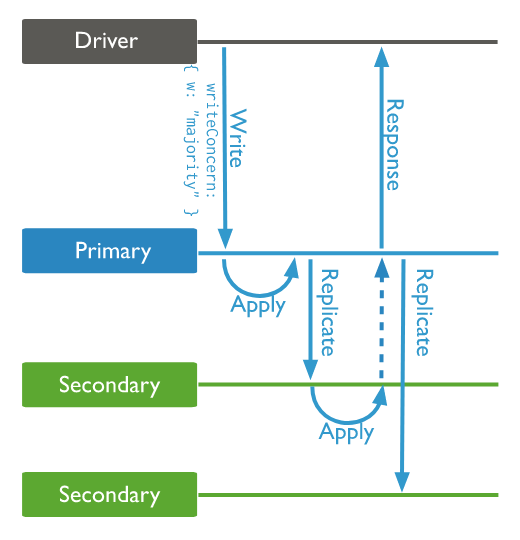



Vérifions cela en pratique mais avant tout regardons la configuration par défaut du niveau de cohérence  :

:::{note} Note

Les liens suivants pourront vous aider pour comprendre le comportement par défaut :

[https://www.mongodb.com/docs/v4.4/reference/mongodb-defaults/#write-concern](https://www.mongodb.com/docs/v4.4/reference/mongodb-defaults/#write-concern)

Pour vérifier la configuration, utiliser la documentation suivante :

[https://www.mongodb.com/docs/v4.4/reference/command/getDefaultRWConcern/#replica-sets](https://www.mongodb.com/docs/v4.4/reference/command/getDefaultRWConcern/#replica-sets)

:::

Vérifions le write concern par défaut de cette version/configuration avant d'interpréter les essais. Les valeurs peuvent dépendre de la version et de la topologie ; dans notre Replica Set à trois membres votants, sans arbitre, le write concern implicite est normalement `majority` (`w: 2`).



Pour personnaliser le comportement par défaut, il est possible de spécifier, lors de la modification, le niveau d'écriture souhaité.

Le write concern `w: 3` demande un acquittement des trois membres. Pour voir le comportement lorsqu'un SECONDARY est indisponible, identifiez d'abord un SECONDARY avec `rs.status()`, puis arrêtez ce conteneur depuis #term1. Ne stoppez pas un PRIMARY pour cette étape.

Vérifiez dans `rs.status()` que le nœud arrêté est indiqué comme indisponible. Les autres terminaux peuvent afficher des erreurs de heartbeat pour ce membre. La majorité des votes restant disponible, le PRIMARY peut continuer à traiter des opérations selon leur write concern.

Essayer de réinsérer votre document :

#### Expliquer le résultat du write concern et distinguer ce comportement ?

:::{admonition} Solution
:class: dropdown

Avec un SECONDARY arrêté, `w: 3` ne peut pas obtenir trois acquittements. Après le délai de `wtimeout`, le client reçoit une erreur de write concern timeout.

Le timeout ne signifie pas que l'écriture est annulée : elle peut déjà avoir été appliquée sur le PRIMARY et l'autre SECONDARY, puis être répliquée après le redémarrage. Cette expérience montre qu'un write concern plus exigeant peut réduire la disponibilité de l'acquittement. 
:::

#### Tester `w: 2` avec le SECONDARY arrêté. Cette valeur correspond à la majorité de deux membres sur trois 


Pour redémarrer le SECONDARY arrêté, exécutez depuis #term1 (remplacez `mongo2` si vous aviez arrêté un autre SECONDARY) :

```bash
docker compose start mongo2
```

Attendez son retour à l'état `SECONDARY` dans `rs.status()`.

Un SECONDARY peut présenter un retard de réplication, y compris en fonctionnement normal. `readConcern: "majority"` évite de lire des données qui ne sont pas validées par la majorité, mais ne garantit pas que la lecture sur un SECONDARY soit la plus récente à l'instant présent.

#### Quelle préférence de lecture choisir pour privilégier la donnée la plus récente ? Et quelle garantie apporte `readConcern: "majority"` ?

:::{admonition} Solution
:class: dropdown

Pour privilégier la lecture la plus récente, utiliser la préférence `primary` : les lectures vont au PRIMARY courant, au prix d'une possible indisponibilité pendant une élection.

`readConcern: "majority"` retourne des données validées par la majorité et réduit le risque de lire une écriture qui serait ensuite annulée après un changement de PRIMARY. Il ne fait pas interroger deux nœuds pour chaque lecture et ne garantit pas qu'un SECONDARY renvoie la valeur la plus récente.

Pour « lire ses propres écritures » avec des lectures secondaires, il faut utiliser une session causale avec des opérations en `majority`. La règle de quorum simplifiée `R + W > N` ne s'applique pas directement aux read/write concerns de MongoDB comme à un système de stockage avec lectures et écritures adressées à un nombre fixe de réplicas.
:::

# Conclusion

Un Replica Set apporte la réplication des données et la haute disponibilité grâce à l'élection d'un PRIMARY. Les préférences de lecture déterminent les membres admissibles ; les lectures sur SECONDARY peuvent être en retard.

Les write concerns déterminent les acquittements attendus, tandis que les read concerns déterminent quelles données une lecture est autorisée à retourner. Ces paramètres influencent latence, disponibilité de l'acquittement et garanties de lecture, mais ne constituent pas à eux seuls un interrupteur CAP.

Le théorème CAP décrit le compromis entre cohérence et disponibilité lorsqu'une partition réseau empêche des membres de communiquer. Il faut distinguer ce scénario d'une simple panne d'un nœud et interpréter les résultats en fonction du quorum encore accessible.